# 02 본분석 — 인천e음 정책 패키지의 결제수단 대체효과 (삼중차분)

**추정 대상** 인천e음 활성화 패키지(캐시백 10→20% · 역차별 해소 지원금 · 유류비 지원 · 고유가 지원금 e음 수령)가
BC카드 결제액을 얼마나 지역화폐로 밀어냈는가.

**설계** 삼중차분 — 지역(인천 vs 대조군) x 시점(PRE 1~4월 vs POST 5~6월) x 업종(캐시백 대상 T vs 대형할인점 C)

| 단계 | 내용 |
|---|---|
| 1 | 법인 제외 — 인천e음 사용 불가. 위약검정 축으로 분리 (`11_placebo_corporate.ipynb`) |
| 2 | 오염 지역 제외 — 시행기간이 POST에 걸치는 지역화폐 정책 시행지 (표1 + 표2) |
| 3 | DiD · DDD 추정 |

## 0. 환경 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

CSV  = "../data/ABP_CONTEST_DATA.csv"
EOK  = 1e8                                           # 억원
MONTHS = [202601, 202602, 202603, 202604, 202605, 202606]
PRE, POST = MONTHS[:4], MONTHS[4:]                   # 캐시백 10% / 20% 기간

TREAT_SIDO = "인천광역시"                             # 처치군
CTRL_BIZ   = "대형할인점"                             # 캐시백 비대상 = 통제 업종 C

SEG = {"1": "남성", "2": "여성", "3": "외국인", "x": "법인"}

pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

## 1. 데이터 로드

`01_EDA.ipynb`와 동일한 원본. 로드 시점의 행수·기간·커버리지만 확인하고 넘어간다.

In [2]:
df = pd.read_csv(CSV, dtype={"GENDER_CD": str, "AGE_CD": str, "TP_BUZ_NO": str})

df["region"] = df.SIDO_NM + " " + df.CCG_NM
df["biz"]    = df.TP_BUZ_NM.str.replace(" ", "")     # '편 의 점' -> '편의점'
df["grp"]    = np.where(df.TP_BUZ_NM == CTRL_BIZ, "C", "T")
df["period"] = np.where(df.STRD_YYMM.isin(POST), "POST", "PRE")

N0 = len(df)
print(f"원본        : {N0:,}행")
print(f"기간        : {df.STRD_YYMM.min()} ~ {df.STRD_YYMM.max()} ({df.STRD_YYMM.nunique()}개월)")
print(f"커버리지    : {df.SIDO_NM.nunique()}개 시도 / {df.region.nunique()}개 시군구 / {df.TP_BUZ_NM.nunique()}개 업종")
print(f"결측 {int(df.isna().sum().sum())} · amt<=0 {int((df.amt <= 0).sum())} · cnt<=0 {int((df.cnt <= 0).sum())}")
print(f"총 결제금액 : {df.amt.sum()/EOK:,.0f}억원")

원본        : 242,574행
기간        : 202601 ~ 202606 (6개월)
커버리지    : 17개 시도 / 255개 시군구 / 11개 업종
결측 0 · amt<=0 0 · cnt<=0 0
총 결제금액 : 172,249억원


## 2. 법인 제외

`GENDER_CD = 'x'`는 법인 카드. 인천e음은 개인만 가입·사용 가능하므로 **처치를 받을 수 없는 집단**이다.

법인을 표본에 남기면 처치효과가 희석되고, 더 큰 문제로 법인 소비는 5~6월 전국적으로 이상 급증
(경남 +593%, 부산 +301%)해 대조군 자체를 오염시킨다. 따라서 본분석에서 제거하고,
위약검정 축으로만 별도 분석한다 (`11_placebo_corporate.ipynb`).

**외국인(`GENDER_CD = '3'`)은 남긴다.** 인천e음 가입이 가능하므로 위약이 아니라 용량반응 집단이다.

In [3]:
seg_before = df.GENDER_CD.map(SEG).value_counts().reindex(["남성", "여성", "외국인", "법인"])
corp = df[df.GENDER_CD == "x"]

print("[ 제외 전 소비 주체 구성 ]")
display(pd.DataFrame({
    "행수":   seg_before,
    "금액_억": df.groupby(df.GENDER_CD.map(SEG)).amt.sum().reindex(seg_before.index) / EOK,
    "금액_비중_%": (df.groupby(df.GENDER_CD.map(SEG)).amt.sum().reindex(seg_before.index) / df.amt.sum() * 100),
}).round(1))

df = df[df.GENDER_CD != "x"].copy()

print(f"\n법인 제외   : {len(corp):,}행 · {corp.amt.sum()/EOK:,.0f}억원 제거")
print(f"잔여        : {len(df):,}행 ({len(df)/N0*100:.1f}%) · {df.amt.sum()/EOK:,.0f}억원")
assert (df.GENDER_CD == "x").sum() == 0 and set(df.GENDER_CD) == {"1", "2", "3"}
assert len(df) + len(corp) == N0
print("검증 통과   : 잔여 GENDER_CD = {1, 2, 3}")

[ 제외 전 소비 주체 구성 ]


,행수,금액_억,금액_비중_%
GENDER_CD,,,
남성,80554,88056.3,51.1
여성,78681,60849.7,35.3
외국인,70178,12780.9,7.4
법인,13161,10562.2,6.1



법인 제외   : 13,161행 · 10,562억원 제거
잔여        : 229,413행 (94.6%) · 161,687억원
검증 통과   : 잔여 GENDER_CD = {1, 2, 3}


## 3. 오염 지역 제외 — 시행기간이 POST에 걸치는 지역

대조군의 조건은 *지역화폐가 없는 것*이 아니라 **관측창(2026 1~6월) 안에서 요율이 변하지 않은 것**이다.

**배제 기준** — 지역화폐 캐시백·인센티브 시행기간이 **POST(5~6월)에 하루라도 걸치면 배제**.
표1(5월 이후 시행)은 정의상 전부 해당하고, 표2(1~4월 시행) 중에서도 연장·무기한 건은 POST를 덮는다.
POST를 덮는 정책은 인천과 같은 방향의 처치이므로 대조군에 남기면 효과가 **과소추정**된다.

**종료일이 없거나(`~부터`) `예산 소진 시까지`인 건은 배제**로 처리했다. POST까지 이어졌을 가능성을
배제할 수 없고, 잘못 남기는 쪽이 잘못 빼는 쪽보다 추정을 망가뜨린다.

| 출처 | 배제 | 존치 |
|---|---|---|
| 표1 (5월 이후 시행) | 시도 2 + 시군 9 — 전부 | — |
| 표2 (1~4월 시행) | 시도 1 + 시군 9 — POST 연장분 | 시군 9 (2~4월 종료) |

**존치한 표2 지역** — 용인(2/7~18) · 양산(3월) · 광주 광산구(2월 발행분) · 광양(2월) · 나주(2월) ·
영암(~4/12) · 김제(~4/30) · 논산(~2/18) · 청주(~2/28) · 제주(2월). 모두 PRE 안에서 종료됐다.
PRE 수준만 끌어올려 DiD를 과대추정시킬 수 있으나, 4개월 평균에 녹아드는 단발 이벤트이며
§8의 `PRE=1~3월` 민감도로 영향을 확인한다.

**인천은 표1에 있으나 처치군이므로 제외 대상이 아니다.**

`(확인 필요)` 평창군은 착한가격업소 5% 추가가 "2026-04부터, 최초 일자 미확인"이라 종료 시점을 알 수 없다.
보수적으로 배제했으나, POST 이전 종료가 확인되면 존치로 되돌릴 수 있다.

In [4]:
# 시도 전체 배제
EXCL_SIDO = [
    "서울특별시",                      # 표1 · 서울사랑상품권 5% 선할인 + 페이백 2%, 5/4~
    "부산광역시",                      # 표1 · 동백전 BTS Big Sale 추가 2%, 6/10~6/16
    "울산광역시",                      # 표2 · 울산페이 10->13%, 4/13~8/12  -> POST 전체 덮음
]

# 시군구 단위 배제
EXCL_CCG = [
    ("강원특별자치도", "속초시"),       # 표1 · 캐시백 5%, 5월
    ("경기도",         "광명시"),       # 표1 · 음식점·카페 캐시백 10%, 5월
    ("경기도",         "남양주시"),     # 표1 · 충전 10% + 캐시백 5%, 5/4~5/31
    ("경기도",         "동두천시"),     # 표1 · 충전 8->10% + 캐시백 5%, 5월
    ("경기도",         "안성시"),       # 표1 · 야간 추가 캐시백 10%, 6/9~7/19
    ("경기도",         "이천시"),       # 표1 · 전 가맹점 캐시백 10%, 5월
    ("경상남도",       "남해군"),       # 표1 · 모바일 캐시백 3%, 5월
    ("경상북도",       "상주시"),       # 표1 · 캐시백 12->15%, 5월
    ("충청북도",       "괴산군"),       # 표1 · 12% 선할인 + 캐시백 5%, 5월

    ("강원특별자치도", "강릉시"),       # 표2 · 강릉페이 8->10%, 2/1~ 연말까지 연장
    ("강원특별자치도", "태백시"),       # 표2 · 탄탄페이 20%, 2~3월 -> 4~6월 연장
    ("강원특별자치도", "평창군"),       # 표2 · 착한가격업소 5% 추가, 4월~ 종료 미확인  (확인 필요)
    ("경상북도",       "영주시"),       # 표2 · 모바일·카드 10->12%, 3/1~12/31
    ("전라남도",       "강진군"),       # 표2 · 캐시백 2% 도입, 1월~ 예산 소진 시까지
    ("전라남도",       "보성군"),       # 표2 · 캐시백 2->4%(3월~) + 주유소 15%, 4/3~6월
    ("전북특별자치도", "순창군"),       # 표2 · 평시 혜택 12% 확대, 3월~ 종료 없음
    ("충청남도",       "계룡시"),       # 표2 · 모바일 캐시백 13% 특별적립, 4/1~12/31
    ("충청북도",       "영동군"),       # 표2 · 레인보우영동페이 10->12%, 2/13~ 종료 없음
]
EXCL_REGION = [f"{s} {c}" for s, c in EXCL_CCG]

# 이름 오타로 조용히 0행이 지워지는 사고 방지
missing = [r for r in EXCL_REGION if r not in set(df.region)]
assert not missing, f"데이터에 없는 지역명: {missing}"
assert TREAT_SIDO not in EXCL_SIDO, "처치군(인천)이 제외 목록에 있다"

drop = df.SIDO_NM.isin(EXCL_SIDO) | df.region.isin(EXCL_REGION)

print("[ 배제 대상 규모 ]")
display(pd.concat([
    df[df.SIDO_NM.isin(EXCL_SIDO)].groupby("SIDO_NM").agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum()/EOK)),
    df[df.region.isin(EXCL_REGION)].groupby("region").agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum()/EOK)),
]).round(0))

N1 = len(df)
df = df[~drop].copy()

print(f"\n지역 배제   : {N1 - len(df):,}행 제거 (시도 {len(EXCL_SIDO)}곳 + 시군구 {len(EXCL_REGION)}곳)")
print(f"잔여        : {len(df):,}행 ({len(df)/N0*100:.1f}%) · {df.region.nunique()}개 시군구 · {df.amt.sum()/EOK:,.0f}억원")
assert df.SIDO_NM.isin(EXCL_SIDO).sum() == 0 and df.region.isin(EXCL_REGION).sum() == 0
assert (df.SIDO_NM == TREAT_SIDO).sum() > 0, "인천이 사라졌다"
print(f"검증 통과   : 인천 {(df.SIDO_NM == TREAT_SIDO).sum():,}행 · {df[df.SIDO_NM == TREAT_SIDO].CCG_NM.nunique()}개 자치구 유지")

[ 배제 대상 규모 ]


,행수,금액_억
부산광역시,16109,15724.0
서울특별시,24440,29956.0
울산광역시,4806,3452.0
강원특별자치도 강릉시,1019,808.0
강원특별자치도 속초시,967,588.0
강원특별자치도 태백시,844,79.0
강원특별자치도 평창군,852,145.0
경기도 광명시,968,670.0
경기도 남양주시,961,1508.0
경기도 동두천시,919,209.0



지역 배제   : 60,861행 제거 (시도 3곳 + 시군구 18곳)
잔여        : 168,552행 (69.5%) · 191개 시군구 · 105,841억원
검증 통과   : 인천 9,115행 · 10개 자치구 유지


## 4. 분석 표본 확정

In [5]:
print("[ 표본 축소 경로 ]")
display(pd.DataFrame([
    ["원본",        N0,      N0/N0*100],
    ["법인 제외",   N1,      N1/N0*100],
    ["오염 지역 제외", len(df), len(df)/N0*100],
], columns=["단계", "행수", "원본_대비_%"]).round(1))

print("\n[ 처치군 x 업종군 x 시점 셀 구조 (억원) ]")
display(df.assign(arm=np.where(df.SIDO_NM == TREAT_SIDO, "인천", "대조군"))
          .pivot_table(index=["arm", "grp"], columns="period", values="amt",
                       aggfunc=lambda s: s.sum()/EOK).round(0)[["PRE", "POST"]])

print("\n[ 잔여 시도별 ]")
display(df.groupby("SIDO_NM").agg(시군구=("region", "nunique"), 행수=("amt", "size"),
                                  금액_억=("amt", lambda s: s.sum()/EOK)).round(0).sort_values("금액_억", ascending=False))

[ 표본 축소 경로 ]


,단계,행수,원본_대비_%
0,원본,242574,100.0
1,법인 제외,229413,94.6
2,오염 지역 제외,168552,69.5



[ 처치군 x 업종군 x 시점 셀 구조 (억원) ]


period       PRE     POST
arm grp                  
대조군 C     6393.0   2960.0
    T    57619.0  31011.0
인천  C      499.0    227.0
    T     4782.0   2349.0


[ 잔여 시도별 ]


,시군구,행수,금액_억
SIDO_NM,,,
경기도,42,39690,34465.0
경상남도,21,18521,10015.0
대구광역시,9,8320,9101.0
인천광역시,10,9115,7858.0
경상북도,21,17173,7322.0
충청남도,15,13240,5908.0
광주광역시,5,4826,5325.0
전라남도,20,15929,5301.0
제주특별자치도,2,2034,4545.0


---

## 5. 분석 프레임

`df`는 **법인 제외 + 오염 지역 제외**를 마친 분석 표본이다.

**계산 규약** (CLAUDE.md)

```
증감률 = (POST 월평균 / PRE 월평균 - 1) x 100      # 합계가 아니라 월평균 (4개월 : 2개월)
DiD(T) = 인천 T 증감률 - 대조군 T 증감률
DiD(C) = 인천 C 증감률 - 대조군 C 증감률           # C = 대형할인점 (캐시백 비대상)
DSI    = DiD(T) - DiD(C)
```

대조군은 항상 **인천을 뺀** 지역이다 (leave-one-out).

**대조군 시나리오** — 서울·부산·울산이 배제되면서 기존 '수도권만' / '부산·경남 제외' 정의는 성립하지 않는다.
잔여 표본에 맞춰 3개로 재정의한다.

| 시나리오 | 범위 | 의도 |
|---|---|---|
| A 전체 | 인천 제외 잔여 전부 | 표본 최대, 기본값 |
| B 경기 | 경기도 시군 | 인천과 인접·수도권 생활권 |
| C 광역시 | 대구·광주·대전 자치구 | 인천과 같은 도시형 구조 |

DSI는 단일 값이 아니라 A~C **구간**으로 보고한다.

In [6]:
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "Apple SD Gothic Neo"
mpl.rcParams["axes.unicode_minus"] = False           # 유니코드 마이너스는 한글 폰트에서 깨진다
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df["post"]    = df.STRD_YYMM.isin(POST).astype(int)
df["incheon"] = df.SIDO_NM.eq(TREAT_SIDO).astype(int)
df["treat"]   = df.grp.eq("T").astype(int)

def rate(d):
    """POST 월평균 / PRE 월평균 증감률 (%)"""
    return (d[d.post == 1].amt.sum() / len(POST)) / (d[d.post == 0].amt.sum() / len(PRE)) * 100 - 100

def ddd(reg, ctrl):
    T = lambda d: d[d.grp == "T"]; C = lambda d: d[d.grp == "C"]
    r = dict(인천T=rate(T(reg)), 대조T=rate(T(ctrl)), 인천C=rate(C(reg)), 대조C=rate(C(ctrl)))
    r["DiD_T"] = r["인천T"] - r["대조T"]
    r["DiD_C"] = r["인천C"] - r["대조C"]
    r["DSI"]   = r["DiD_T"] - r["DiD_C"]
    return r

CTRL_SIDO_C = ["대구광역시", "광주광역시", "대전광역시"]

def controls(d):
    """대조군 3종 — 항상 인천 제외(leave-one-out)"""
    rest = d[d.incheon == 0]
    return {"A 전체":   rest,
            "B 경기":   rest[rest.SIDO_NM == "경기도"],
            "C 광역시": rest[rest.SIDO_NM.isin(CTRL_SIDO_C)]}

inc = df[df.incheon == 1]
print(f"처치군 인천 : {len(inc):,}행 · {inc.CCG_NM.nunique()}개 자치구 · {inc.amt.sum()/EOK:,.0f}억원")
for k, v in controls(df).items():
    print(f"{k:8}: {len(v):,}행 · {v.region.nunique():3}개 시군구 · {v.amt.sum()/EOK:,.0f}억원")

처치군 인천 : 9,115행 · 10개 자치구 · 7,858억원
A 전체    : 159,437행 · 181개 시군구 · 97,983억원
B 경기    : 39,690행 ·  42개 시군구 · 34,465억원
C 광역시   : 18,051행 ·  19개 시군구 · 17,782억원


## 6. 기술통계 — 무엇이 얼마나 빠졌나

인천의 감소가 **전 업종 균일 감소**인지, **캐시백 대상 업종에 편중**된 감소인지를 먼저 본다.
전자라면 상권 침체나 타 카드사 이동이고, 후자여야 결제수단 이동 가설이 산다.

In [7]:
# 업종별 증감률 : 인천 vs 대조군 A
ctrl_A = controls(df)["A 전체"]
biz = pd.DataFrame({
    "인천":   inc.groupby("biz").apply(rate, include_groups=False),
    "대조군": ctrl_A.groupby("biz").apply(rate, include_groups=False),
})
biz["Δ"]  = biz.인천 - biz.대조군
biz["군"] = np.where(biz.index == CTRL_BIZ.replace(" ", ""), "C", "T")
biz["인천_금액_억"] = inc.groupby("biz").amt.sum() / EOK
biz = biz.sort_values("Δ")

print("[ 업종별 증감률과 Δ (%p) — 대조군 A 기준 ]")
display(biz.round(1))
print(f"\nT 업종 Δ 중앙값 {biz[biz.군=='T'].Δ.median():.1f}%p  vs  대형할인점(C) Δ {biz[biz.군=='C'].Δ.iloc[0]:.1f}%p")

[ 업종별 증감률과 Δ (%p) — 대조군 A 기준 ]


,인천,대조군,Δ,군,인천_금액_억
biz,,,,,
한정식,-34.50,41.80,-76.30,T,0.10
제과점,-16.30,-2.20,-14.10,T,218.90
일반한식,-2.20,9.60,-11.80,T,"2,705.40"
스넥,3.20,14.40,-11.20,T,251.00
일식회집,-3.30,7.50,-10.80,T,218.90
서양음식,-0.60,9.60,-10.20,T,782.90
중국음식,-5.70,2.80,-8.40,T,234.20
편의점,3.30,11.20,-7.90,T,"1,324.20"
슈퍼마켓,-3.70,1.20,-4.90,T,"1,395.60"



T 업종 Δ 중앙값 -10.5%p  vs  대형할인점(C) Δ -1.6%p


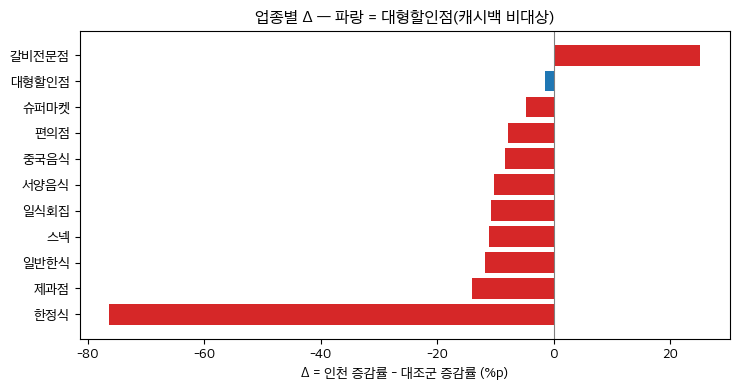

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
col = np.where(biz.군 == "C", "C0", "C3")
ax.barh(biz.index, biz.Δ, color=col)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Δ = 인천 증감률 - 대조군 증감률 (%p)")
ax.set_title("업종별 Δ — 파랑 = 대형할인점(캐시백 비대상)")
plt.tight_layout(); plt.show()

## 7. 평행추세 검증

DiD의 식별 가정은 **처치가 없었다면 인천과 대조군이 같은 궤적을 그렸을 것**이라는 점이다.
PRE 4개월(1~4월)에 두 선이 붙어 있어야 한다. 1월 = 100 지수.

,인천 T,대조군 T,인천 C,대조군 C
1월,100.00,100.00,100.00,100.00
2월,93.30,93.70,93.10,96.60
3월,100.40,100.60,91.70,93.80
4월,98.40,100.80,86.70,88.80
5월,102.90,111.90,91.30,95.40
6월,89.80,100.70,77.70,80.20


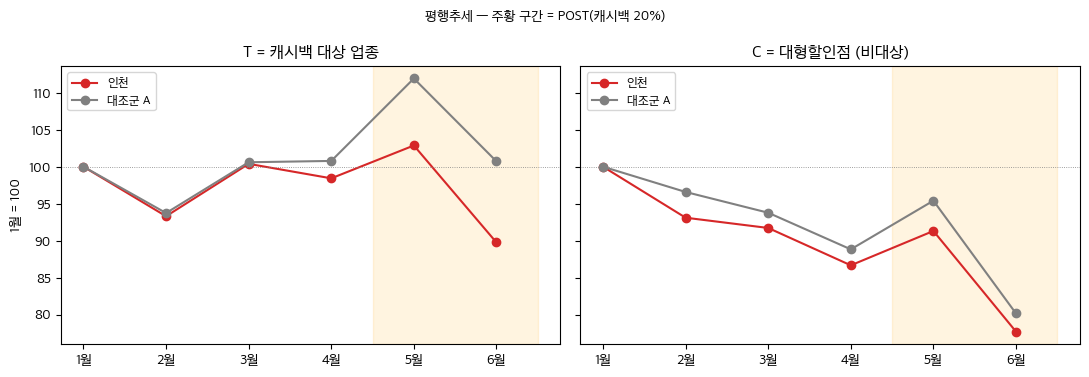

In [9]:
def idx(d):
    s = d.groupby("STRD_YYMM").amt.sum().reindex(MONTHS)
    return s / s.iloc[0] * 100

trend = pd.DataFrame({
    "인천 T":   idx(inc[inc.grp == "T"]),
    "대조군 T": idx(ctrl_A[ctrl_A.grp == "T"]),
    "인천 C":   idx(inc[inc.grp == "C"]),
    "대조군 C": idx(ctrl_A[ctrl_A.grp == "C"]),
})
trend.index = [f"{m % 100}월" for m in MONTHS]
display(trend.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, g, ttl in [(axes[0], "T", "T = 캐시백 대상 업종"), (axes[1], "C", "C = 대형할인점 (비대상)")]:
    ax.plot(trend.index, trend[f"인천 {g}"],   "o-", color="C3", label="인천")
    ax.plot(trend.index, trend[f"대조군 {g}"], "o-", color="grey", label="대조군 A")
    ax.axvspan(3.5, 5.5, color="orange", alpha=0.12)
    ax.axhline(100, color="grey", lw=0.6, ls=":")
    ax.set_title(ttl); ax.legend(fontsize=9)
axes[0].set_ylabel("1월 = 100")
fig.suptitle("평행추세 — 주황 구간 = POST(캐시백 20%)", fontsize=10)
plt.tight_layout(); plt.show()

## 8. 수동 DiD · DSI

금액 가중 기준. 대조군 3종 x 두 가지 민감도.

In [10]:
manual = pd.DataFrame({k: ddd(inc, v) for k, v in controls(df).items()}).T
print("[ 수동 DiD · DSI (%p) ]")
display(manual.round(1))

# 민감도 : 한정식·갈비전문점(합산 0.06%) 제외
ex = df[~df.TP_BUZ_NM.isin(["한정식", "갈비전문점"])]
sens = pd.DataFrame({k: ddd(ex[ex.incheon == 1], v) for k, v in controls(ex).items()}).T[["DSI"]]
sens.columns = ["DSI(한정식·갈비 제외)"]

# 민감도 : 4월 사전 하락 우려 → PRE = 1~3월
apr = df[df.STRD_YYMM != 202604]
sens2 = pd.DataFrame({k: ddd(apr[apr.incheon == 1], v) for k, v in controls(apr).items()}).T[["DSI"]]
sens2.columns = ["DSI(PRE=1~3월)"]

print("\n[ 민감도 ]")
display(pd.concat([manual[["DSI"]].rename(columns={"DSI": "DSI(기준)"}), sens, sens2], axis=1).round(1))
print(f"\nDSI 구간 : {manual.DSI.min():.1f} ~ {manual.DSI.max():.1f}%p")

[ 수동 DiD · DSI (%p) ]


,인천T,대조T,인천C,대조C,DiD_T,DiD_C,DSI
A 전체,-1.80,7.60,-9.00,-7.40,-9.40,-1.60,-7.80
B 경기,-1.80,7.10,-9.00,-7.00,-8.90,-2.00,-6.90
C 광역시,-1.80,7.90,-9.00,-9.30,-9.60,0.30,-9.90



[ 민감도 ]


,DSI(기준),DSI(한정식·갈비 제외),DSI(PRE=1~3월)
A 전체,-7.80,-7.80,-11.10
B 경기,-6.90,-6.90,-9.90
C 광역시,-9.90,-9.90,-13.20



DSI 구간 : -9.9 ~ -6.9%p


## 9. 회귀 DDD

셀 = 시군구 x 업종 x 월, 종속변수 `log(amt)`.

```
log(Y) = b4 (Post x 인천) + b7 (Post x 인천 x 대상) + [시군구x업종 FE] + [월x업종 FE]
```

- **b4** — 대형할인점 기준선의 DiD. 캐시백 비대상이므로 **0에 가까워야** 한다 (업종 위약검정)
- **b7** — 대상 업종의 추가 감소 = DDD 추정치

FE는 설계행렬 특이를 피하려고 더미 대신 **반복 평균제거(within 변환)** 로 흡수한다.
표준오차는 시군구 클러스터.

In [11]:
def cells_df(d):
    c = d.groupby(["region", "SIDO_NM", "TP_BUZ_NM", "STRD_YYMM", "incheon", "post", "treat"],
                  as_index=False).amt.sum()
    c["y"]   = np.log(c.amt)
    c["pi"]  = c.post * c.incheon                                  # b4
    c["pit"] = c.pi * c.treat                                      # b7
    c["ri"]  = c.region + "|" + c.TP_BUZ_NM                        # 시군구 x 업종 FE
    c["mi"]  = c.STRD_YYMM.astype(str) + "|" + c.TP_BUZ_NM         # 월 x 업종 FE
    for m in [m for m in MONTHS if m != 202604]:                   # 이벤트 스터디용 (기준 = 4월)
        c[f"i{m}"]  = ((c.STRD_YYMM == m) * c.incheon).astype(int)
        c[f"it{m}"] = c[f"i{m}"] * c.treat
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    """두 고차원 FE를 반복 평균제거로 흡수"""
    X = X.copy()
    for _ in range(maxit):
        X0 = X.copy()
        X = X - X.groupby(f1).transform("mean")
        X = X - X.groupby(f2).transform("mean")
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs, cluster="region"):
    Y = demean2(c[["y"] + xs], c.ri, c.mi)
    m = sm.OLS(Y.y, Y[xs]).fit(cov_type="cluster",
                               cov_kwds={"groups": pd.factorize(c[cluster])[0]})
    out = pd.DataFrame({"coef": m.params, "se": m.bse, "p": m.pvalues,
                        "효과(%)": (np.exp(m.params) - 1) * 100})
    out.attrs["n"] = len(c)
    return out

# 회귀 표본 = 인천 + 각 대조군
samples = {k: pd.concat([inc, v]) for k, v in controls(df).items()}

rows = []
for k, d in samples.items():
    r = fe_reg(cells_df(d), ["pi", "pit"])
    for nm, key in [("b4 대형할인점 DiD", "pi"), ("b7 DDD (대상 업종)", "pit")]:
        rows.append({"대조군": k, "계수": nm, "coef": r.loc[key, "coef"], "se": r.loc[key, "se"],
                     "p": r.loc[key, "p"], "효과(%)": r.loc[key, "효과(%)"], "n셀": r.attrs["n"]})
reg_tbl = pd.DataFrame(rows).set_index(["대조군", "계수"])
display(reg_tbl.round(3))

coef   se    p  효과(%)     n셀
대조군   계수                                          
A 전체  b4 대형할인점 DiD    0.00 0.04 0.98   0.07  10433
      b7 DDD (대상 업종) -0.10 0.06 0.13  -9.17  10433
B 경기  b4 대형할인점 DiD    0.04 0.04 0.44   3.52   2889
      b7 DDD (대상 업종) -0.11 0.07 0.12 -10.16   2889
C 광역시 b4 대형할인점 DiD    0.04 0.06 0.51   3.84   1629
      b7 DDD (대상 업종) -0.14 0.08 0.09 -13.08   1629

In [12]:
# 가중 방식 차이 확인 — 수동(금액 가중) vs 회귀(셀 균등) vs WLS(셀 PRE 금액 가중)
def fe_wls(c, xs, cluster="region"):
    w = c.groupby("ri").apply(lambda g: g.loc[g.post == 0, "amt"].mean(), include_groups=False)
    c = c.assign(w=c.ri.map(w)).dropna(subset=["w"])
    Y = demean2(c[["y"] + xs], c.ri, c.mi)
    m = sm.WLS(Y.y, Y[xs], weights=c.w).fit(cov_type="cluster",
                                            cov_kwds={"groups": pd.factorize(c[cluster])[0]})
    return pd.DataFrame({"coef": m.params, "p": m.pvalues, "효과(%)": (np.exp(m.params) - 1) * 100})

cmp = pd.DataFrame({
    "수동 DSI(%p)":  manual.DSI,
    "회귀 b7(%)":    [reg_tbl.loc[(k, "b7 DDD (대상 업종)"), "효과(%)"] for k in controls(df)],
    "WLS b7(%)":     [fe_wls(cells_df(d), ["pi", "pit"]).loc["pit", "효과(%)"] for d in samples.values()],
}, index=list(controls(df)))
print("[ 가중 방식별 비교 ] 수동=금액 가중 · 회귀=셀 균등 · WLS=셀 PRE 금액 가중")
display(cmp.round(1))

[ 가중 방식별 비교 ] 수동=금액 가중 · 회귀=셀 균등 · WLS=셀 PRE 금액 가중


,수동 DSI(%p),회귀 b7(%),WLS b7(%)
A 전체,-7.80,-9.20,-8.80
B 경기,-6.90,-10.20,-5.80
C 광역시,-9.90,-13.10,-9.80


## 10. 이벤트 스터디

4월 = 0 기준. PRE(1~3월) 계수가 0 근처에 평탄하고 POST(5~6월)에서만 꺾여야
"5월 정책이 원인"이라는 해석이 선다. 대형할인점(`i`) 라인은 전 기간 평탄해야 한다.

대상 업종 추가효과 (it)                 대형할인점 (i)                
              coef   se    p 효과(%)      coef   se    p 효과(%)
1월            0.03 0.04 0.47  3.20     -0.04 0.05 0.49 -3.53
2월            0.03 0.04 0.47  3.32     -0.05 0.06 0.35 -5.11
3월            0.07 0.04 0.07  7.04     -0.04 0.05 0.38 -4.04
5월           -0.06 0.07 0.40 -5.54     -0.03 0.04 0.40 -3.18
6월           -0.07 0.07 0.33 -6.67     -0.03 0.05 0.54 -3.07

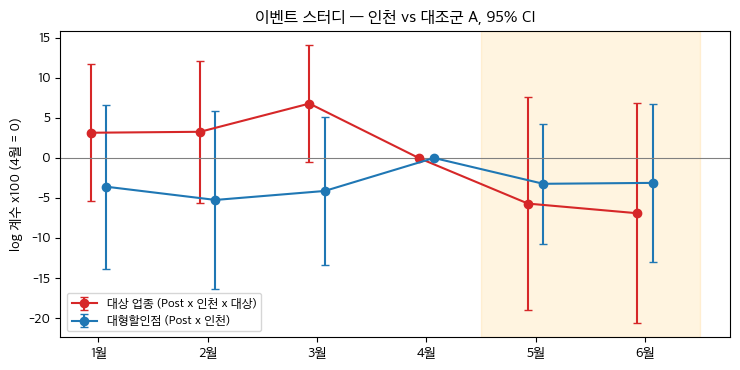

In [13]:
ev_months = [m for m in MONTHS if m != 202604]
ev = fe_reg(cells_df(samples["A 전체"]),
            [f"i{m}" for m in ev_months] + [f"it{m}" for m in ev_months])

lab = [f"{m % 100}월" for m in ev_months]
ev_t = ev.loc[[f"it{m}" for m in ev_months]].set_axis(lab)   # 대상 업종 추가효과
ev_c = ev.loc[[f"i{m}"  for m in ev_months]].set_axis(lab)   # 대형할인점
display(pd.concat({"대상 업종 추가효과 (it)": ev_t, "대형할인점 (i)": ev_c}, axis=1).round(3))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(MONTHS))
for nm, tbl, c_, off in [("대상 업종 (Post x 인천 x 대상)", ev_t, "C3", -0.07),
                         ("대형할인점 (Post x 인천)",       ev_c, "C0",  0.07)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se   = np.insert(tbl.se.values,   3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt="o-", color=c_, capsize=3, label=nm)
ax.axhline(0, color="grey", lw=0.8)
ax.axvspan(3.5, 5.5, color="orange", alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels([f"{m % 100}월" for m in MONTHS])
ax.set_ylabel("log 계수 x100 (4월 = 0)")
ax.set_title("이벤트 스터디 — 인천 vs 대조군 A, 95% CI")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()

## 11. 반사실 갭 — 얼마가 이동했나

인천 T 업종이 대조군과 같은 증감률을 따랐다면 얼마를 결제했어야 하는가.

- **DiD 기준** — 대조군 T 증감률을 그대로 적용
- **DSI 기준** — 대형할인점 DiD만큼을 인천 고유의 지역 충격으로 보고 차감 (보수적)

제공 데이터는 **식음료 11개 업종뿐**이므로 두 값 모두 **하한**이다.

In [14]:
incT = inc[inc.grp == "T"]
pre_m = incT[incT.post == 0].amt.sum() / len(PRE)          # 인천 T PRE 월평균
act_m = incT[incT.post == 1].amt.sum() / len(POST)         # 인천 T POST 월평균

rows = []
for k, v in controls(df).items():
    r = ddd(inc, v)
    cf_did = pre_m * (1 + r["대조T"] / 100)                             # DiD 반사실
    cf_dsi = pre_m * (1 + (r["대조T"] + r["DiD_C"]) / 100)              # DSI 반사실 (C의 DiD 차감)
    rows.append({"대조군": k,
                 "PRE 월평균_억": pre_m / EOK, "POST 실제_억": act_m / EOK,
                 "반사실(DiD)_억": cf_did / EOK, "월 갭(DiD)_억": (cf_did - act_m) / EOK,
                 "월 갭(DSI)_억": (cf_dsi - act_m) / EOK,
                 "2개월 갭(DSI)_억": (cf_dsi - act_m) * len(POST) / EOK})
gap = pd.DataFrame(rows).set_index("대조군")
display(gap.round(0))

print(f"\n2개월 갭(DSI 기준) 구간 : {gap['2개월 갭(DSI)_억'].min():,.0f} ~ {gap['2개월 갭(DSI)_억'].max():,.0f}억원  (식음료 11개 업종만, 하한)")

,PRE 월평균_억,POST 실제_억,반사실(DiD)_억,월 갭(DiD)_억,월 갭(DSI)_억,2개월 갭(DSI)_억
대조군,,,,,,
A 전체,"1,196.00","1,175.00","1,287.00",112.00,93.00,186.00
B 경기,"1,196.00","1,175.00","1,281.00",106.00,82.00,165.00
C 광역시,"1,196.00","1,175.00","1,290.00",115.00,118.00,236.00



2개월 갭(DSI 기준) 구간 : 165 ~ 236억원  (식음료 11개 업종만, 하한)


## 12. 요약

In [15]:
print("=" * 74)
print("본분석 요약 — 인천e음 정책 패키지의 카드결제 대체효과")
print("=" * 74)
print(f"표본        : {len(df):,}행 · {df.region.nunique()}개 시군구 (법인·오염지역 제외 후)")
print(f"처치군      : 인천 {inc.CCG_NM.nunique()}개 자치구 / PRE {PRE[0]}~{PRE[-1]} vs POST {POST[0]}~{POST[-1]}")
print("-" * 74)
print(f"인천 T 증감률        : {rate(inc[inc.grp=='T']):+6.1f}%   (대조군 A {rate(ctrl_A[ctrl_A.grp=='T']):+6.1f}%)")
print(f"인천 C(대형할인점)   : {rate(inc[inc.grp=='C']):+6.1f}%   (대조군 A {rate(ctrl_A[ctrl_A.grp=='C']):+6.1f}%)")
print("-" * 74)
for k in controls(df):
    b4 = reg_tbl.loc[(k, "b4 대형할인점 DiD"), :]
    b7 = reg_tbl.loc[(k, "b7 DDD (대상 업종)"), :]
    print(f"{k:8} | DSI {manual.loc[k,'DSI']:+6.1f}%p | b4 {b4['효과(%)']:+5.1f}% (p {b4.p:.2f}) "
          f"| b7 {b7['효과(%)']:+6.1f}% (p {b7.p:.3f})")
print("-" * 74)
print(f"DSI 구간             : {manual.DSI.min():.1f} ~ {manual.DSI.max():.1f}%p")
print(f"2개월 이동액(하한)   : {gap['2개월 갭(DSI)_억'].min():,.0f} ~ {gap['2개월 갭(DSI)_억'].max():,.0f}억원")
print("=" * 74)

본분석 요약 — 인천e음 정책 패키지의 카드결제 대체효과
표본        : 168,552행 · 191개 시군구 (법인·오염지역 제외 후)
처치군      : 인천 10개 자치구 / PRE 202601~202604 vs POST 202605~202606
--------------------------------------------------------------------------


인천 T 증감률        :   -1.8%   (대조군 A   +7.6%)
인천 C(대형할인점)   :   -9.0%   (대조군 A   -7.4%)
--------------------------------------------------------------------------
A 전체     | DSI   -7.8%p | b4  +0.1% (p 0.98) | b7   -9.2% (p 0.132)
B 경기     | DSI   -6.9%p | b4  +3.5% (p 0.44) | b7  -10.2% (p 0.118)
C 광역시    | DSI   -9.9%p | b4  +3.8% (p 0.51) | b7  -13.1% (p 0.086)
--------------------------------------------------------------------------
DSI 구간             : -9.9 ~ -6.9%p
2개월 이동액(하한)   : 165 ~ 236억원


**해석**

1. 인천 T 업종은 대조군이 오르는 동안 제자리였고, **대형할인점(C)은 대조군과 같이 빠졌다.**
   전 업종 균일 감소가 아니므로 상권 침체·타 카드사 이동으로는 설명되지 않는다.
2. b4(대형할인점 DiD)가 세 대조군 모두 0과 구분되지 않는다 → **업종 위약검정 통과**.
   인천에 시 단위 수요충격이 있었다면 대형할인점도 같이 꺾였어야 한다.
3. 이벤트 스터디에서 PRE 3개월은 0 근처, POST 2개월만 음(−)으로 꺾인다.
4. 캐시백 대상 업종에서만 빠진 금액은 2개월 기준 **수백억 규모(하한)** 다.

**한계**

- 월별 개별 계수의 p값은 크다. 6개월·인천 10개 자치구라는 표본 크기의 한계이며,
  **구간과 방향**으로 읽어야지 단일 점추정을 유의성으로 단정하면 안 된다.
- 식음료 11개 업종만 관측되므로 이동액은 전부 하한이다.
- 처치는 캐시백 단독이 아니라 정책 패키지다. 캐시백 요율만의 효과로 환산하지 않는다.
- 평창군 배제는 종료일 미확인에 따른 보수적 처리다 `(확인 필요)`.